import lines

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [283]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [284]:
df.shape

(150, 5)

In [285]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [287]:
#missing = df.isnull().sum().sort_values(ascending=False)
#missing_percent = (missing / len(df) * 100).round(2)
#pd.DataFrame({"Missing": missing, "Missing %": missing_percent})[missing > 0]

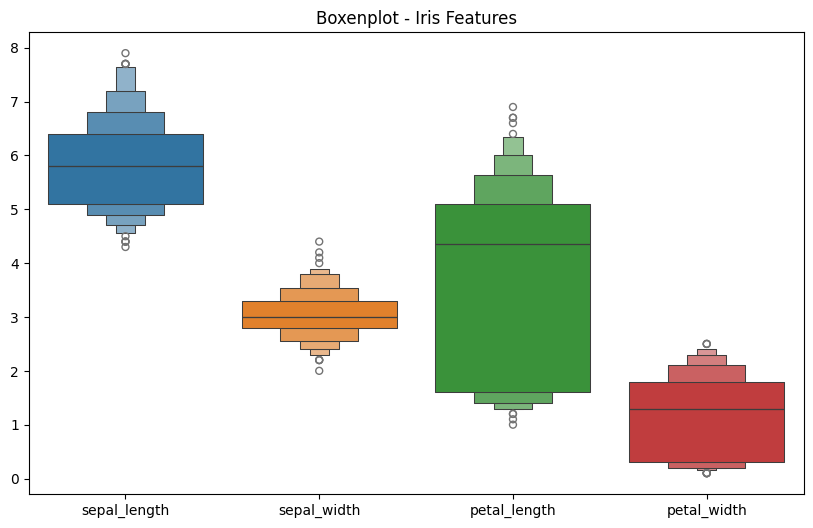

In [288]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df.drop(columns=["species"]))
plt.title("Boxenplot - Iris Features")
plt.show()

In [289]:
Q1 = df["sepal_width"].quantile(0.25)
Q3 = df["sepal_width"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["sepal_width"] < lower) | (df["sepal_width"] > upper)]
print("Number of outliers in sepal_width:", len(outliers))
print(f"Lower bound: {lower:.4f}")
print(f"Upper bound: {upper:.4f}")

Number of outliers in sepal_width: 4
Lower bound: 2.0500
Upper bound: 4.0500


In [290]:
outlier_mask = (df["sepal_width"] < lower) | (df["sepal_width"] > upper)
print(f"\nIdentified {outlier_mask.sum()} outlier rows in 'sepal_width'.")

df_clean = df[~outlier_mask].copy()
print(f"Dataset shape after cleaning: {df_clean.shape}")


Identified 4 outlier rows in 'sepal_width'.
Dataset shape after cleaning: (146, 5)


In [291]:
X = df.drop(columns=["species"])
y = df["species"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [292]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear", "poly", "sigmoid"],
}

base_svm = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=base_svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
)

In [294]:
grid_search.fit(X_train_scaled, y_train)

print("Best Hyperparameters found:")
print(grid_search.best_params_)
print(f"Best 5-Fold Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%\n")

best_svm_model = grid_search.best_estimator_




Best Hyperparameters found:
{'C': 0.1, 'kernel': 'linear'}
Best 5-Fold Cross-Validation Accuracy: 97.50%



Test Set Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



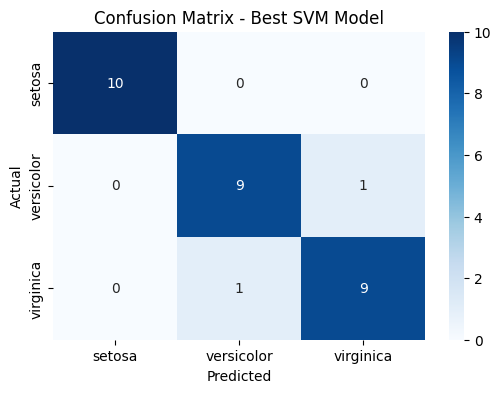

In [ ]:
y_pred = best_svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")#Ali
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_svm_model.classes_,
    yticklabels=best_svm_model.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best SVM Model")
plt.show()